###6.1.1 LeNet-5 사용 예제 구현

In [1]:
!pip install --user tqdm

↪ tqdm 라이브러리 설치
* 진행 상태를 바 형태로 가시화해 보여줌
* 주로 모델 훈련에 대한 진행 상태 확인하고자 할 때 사용

In [2]:
#필요한 라이브러리 호출
import torch
import torchvision
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms    #이미지 변환(전처리) 기능 제공하는 라이브러리
from torch.autograd import Variable
from torch import optim     #경사 하강법을 이용하여 가중치를 구하기 위한 옵티마이저 라이브러리
import torch.nn as nn
import torch.nn.functional as F
import os       #파일 경로에 대한 함수들을 제공
import cv2
from PIL import Image
from tqdm import tqdm_notebook as tqdm      #진행 상황을 가시적으로 표현해 주는데, 특히 모델의 학습 경과를 확인하고 싶을 때 사용하는 라이브러리
import random
from matplotlib import pyplot as plt

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
#파이토치는 텐서플로와 다르게 GPU를 자동 할당해주지 않기 때문에 GPU 할당을 모델과 데이터에 선언해주어여 함

In [3]:
#이미지 데이터셋 전처리
class ImageTransform():
    def __init__(self, resize, mean, std):
        self.data_transform = {
            'train': transforms.Compose([
                transforms.RandomResizedCrop(resize, scale=(0.5,1.0)),
                transforms.RandomHorizontalFlip(),
                transforms.ToTensor(),
                transforms.Normalize(mean, std)
            ]),     #①
            'val': transforms.Compose([
                transforms.Resize(256),
                transforms.CenterCrop(resize),
                transforms.ToTensor(),
                transforms.Normalize(mean, std)
            ])
        }

    def __call__(self, img, phase):     #②
        return self.data_transform[phase](img)

↪ ① 토치비전 라이브러리를 이용하면 이미지에 대한 전처리를 손쉽게 할 수 있음
* `torch.transforms`에서 사용하는 파라미터
    * `transforms.Compose`: 이미지를 변형할 수 있는 방식들의 묶음
    * `transforms.RandomResizedCrop`: 입력 이미지를 주어진 크기로 조정. scale은 원래 이미지를 임의의 크기만큼 면적을 무작위로 자르겠다는 의미
    * `transforms.RandomHorizaontalFlip`: 주어진 확률로 이미지를 수평 반전. 확률 값 지정하지 않는 경우 기본값인 0.5의 확률로 이미지들이 수평반전됨
    * `transforms.ToTensor`: `ImageFolder` 메서드를 비롯한 `torchvision` 메서드는 이미지를 읽을 때 파이썬 이미지 라이브러리인 PIL을 사용.
        * PIL을 이용해 이미지를 읽으면 생성되는 이미지는 범위가 [0, 255]이며 배열의 차원이 (높이 H x 너비 W x 채널 수 C)로 표현됨
        * 이후 효율적인 연산을 위해 `torch.FloatTensor` 배열로 바꾸어야 하는데 이때 픽셀 값의 범위는 [0.0, 1.0] 사이가 되고 차원의 순서도 (채널 수 C x 높이 H x 너비 W)로 바뀜
    * `transforms.Normalize`: 전이 학습에서 사용하는 사전 훈련된 모델들은 대개 ImageNet 데이터셋에서 훈련됨. 따라서 사전 훈련된 모델을 사용하기 위해서는 ImageNEt 데이터의 각 채널별 평균과 표준편차에 맞는 정규화를 해 주어야 함
        * Normalize 메서드 안에 사용된 mean, std는 ImageNet에서 이미지들의 RGB 채널마다 평균과 표준편차를 의미
        * OpenCV를 사용해 이미지를 읽어 온다면 RGB가 아닌 BGR이미지이므로 채널 순서에 주의
    * `__call__` 함수는 클래스를 호출할 수 있도록 하는 메서드
        * `__init__`은 인스턴스 초기화를 위해 사용한다면 `__call__`은 인스턴스가 호출되었을 때 실행됨
        * 클래스에 `__call__`함수가 있을 경우 클래스 객체 자체를 호출하면 `__call__`함수의 리턴 값이 반환됨

In [4]:
#이미지 데이터셋을 불러온 후 훈련, 검증, 테스트로 분리
cat_directory = r'/content/drive/MyDrive/Euron_9기DL/data/dogs-vs-cats/Cat'
dog_directory = r'/content/drive/MyDrive/Euron_9기DL/data/dogs-vs-cats/Dog'

cat_images_filepaths = sorted([os.path.join(cat_directory, f) for f in
                               os.listdir(cat_directory)])      #①
dog_images_filepaths = sorted([os.path.join(dog_directory, f) for f in
                               os.listdir(dog_directory)])
images_filepaths = [*cat_images_filepaths, *dog_images_filepaths]       #개와 고양이 이미지들을 합쳐서 images_filepaths에 저장
correct_images_fliepaths = [i for i in images_filepaths if cv2.imread(i) is not None]       #②

random.seed(42)     #③
random.shuffle(correct_images_fliepaths)
train_images_filepaths = correct_images_fliepaths[:400]     #훈련용 400개의 이미지
val_images_filepaths = correct_images_fliepaths[400:-10]        #검증용 92개의 이미지
test_images_filepaths = correct_images_fliepaths[-10:]      #테스트용 10개의 이미지
print(len(train_images_filepaths), len(val_images_filepaths), len(test_images_filepaths))

400 92 10


↪ ① 고양이 이미지 데이터를 가져옴
* `sorted`: 데이터를 정렬된 리스트로 만들어서 반환
* `os.path.join`: 경로와 파일명을 결합하거나 분할된 경로를 하나로 합치고 싶을 때 사용
    * `cat_directory` 디렉터리와 `os.listdir`을 통해 검색된 이미지 파일들(`f`)을 하나로 합쳐서 '../dogs-vs-cats/Cat/이미지파일명'으로 표시해줌
    * `os.listdir`: 지정한 디렉터리 내 모든 파일의 리스트를 반환
    * 다음과 같이 경로를 하나로 합칠 수 있음

In [5]:
#예시 코드
import os
list_path = ['C:\\', 'Temp', 'user']
folder_path = os.path.join(*list_path)
folder_path

'C:\\/Temp/user'

↪ 실행 결과로 경로가 하나로 합쳐 있는 것을 확인 할 수 있음



---



② `images_filepath`에서 이미지 파일들을 불러옴
* `for` 반복문을 이용하여 가져온 데이터에 대해 i를 이용하여 리스트를 만듬
* 반복문(`for`)을 이용하여 images_filepaths에서 이미지 데이터를 검색
* 조건문(`if`)을 의미, `cv2.imread()` 함수(`cv2.imread(i)`)를 이용하여 모든 이미지 데이터를 읽어 옴(`not None` 상태는 더 이상 데이터를 찾을 수 없을 때까지를 의미)

③ 넘파이 `random()` 함수는 임의의 난수를 생성하는데, 이때 난수를 생성하기 위해 사용되는 것이 시드 값
* `Numpy.random.seed()` 메서드는 상태를 초기화함, 즉 이 모듈이 호출될 때마다 임의의 난수가 재생성됨
* 특정 시드 값을 부여하면 상태가 저장되기 때문에 동일한 난수를 생성

In [6]:
#예시 코드
import numpy as np

np.random.seed(101)
np.random.randint(low=1, high=10, size=10)

array([2, 7, 8, 9, 5, 9, 6, 1, 6, 9])

In [7]:
np.random.seed(100)
np.random.randint(low=1, high=10, size=10)

array([9, 9, 4, 8, 8, 1, 5, 3, 6, 3])

In [8]:
np.random.seed(101)
np.random.randint(low=1, high=10, size=10)

array([2, 7, 8, 9, 5, 9, 6, 1, 6, 9])



---



In [9]:
#테스트 데이터셋 이미지 확인 함수
def display_image_grid(images_filepaths, predicted_labels=(), cols=5):
    rows = len(images_filepaths) // cols
    figure, ax = plt.subplots(nrows=rows, ncols=cols, figsize=(12, 6))
    for i, images_filepath in enumerate(images_filepaths):
        image = cv2.imread(images_filepath)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)      #①
        true_label = os.path.normpath(images_filepath).split(os.sep)[-2]        #②
        predicted_label = predicted_labels[i] if predicted_labels else true_label       #③
        color = "green" if true_label == predicted_label else "red"     #예측과 정답(레이블)이 동일하면 초록색, 아니면 빨간색으로 표시
        ax.ravel()[i].imshow(image)     #개별 이미지를 출력
        ax.ravel()[i].set_title(predicted_label, color=color)       #predicted_label을 타이틀로 사용
        ax.ravel()[i].set_axis_off()        #이미지의 축 제거
    plt.tight_layout()      #이미지의 여백을 조정
    plt.show()

↪ ① `cv2.cvtColor`는 이미지의 색상을 변경하기 위해 사용됨
* 첫 번째 파라미터: 입력 이미지
* 두 번째 파라미터: 변환할 이미지의 색상을 지정하는 것으로 BGR채널 이미지를 RGB로 변경하겠다는 의미

② 이미지의 전체 경로를 정규화하고 분할을 위한 코드
* `os.path.normpath`: 경로명을 정규화
    * A//B, A/B/. A/./B 및 A//../B 모두 A/B로 경로 통일
* `split(os.sep)`: 경로를 / 혹은 \를 기준으로 분할할 때 사용
    * c:/temp/user/a.jpg라는 경로가 있을 때 split(os.sep)을 적용하면 ['c:', 'temp', 'user', 'a.jpg']처럼 분할
    * `split(os.sep)[-2]`를 적용하면 'user'를 반환

③ `predicted_label`에 대한 값을 정의하기 위한 코드
* `predicted_labels` 값이 있으면 그 값을 `predicted_label`로 사용
* `predicted_labels`에 값이 없다면 `true_label` 값을 `predicted_label`로 사용

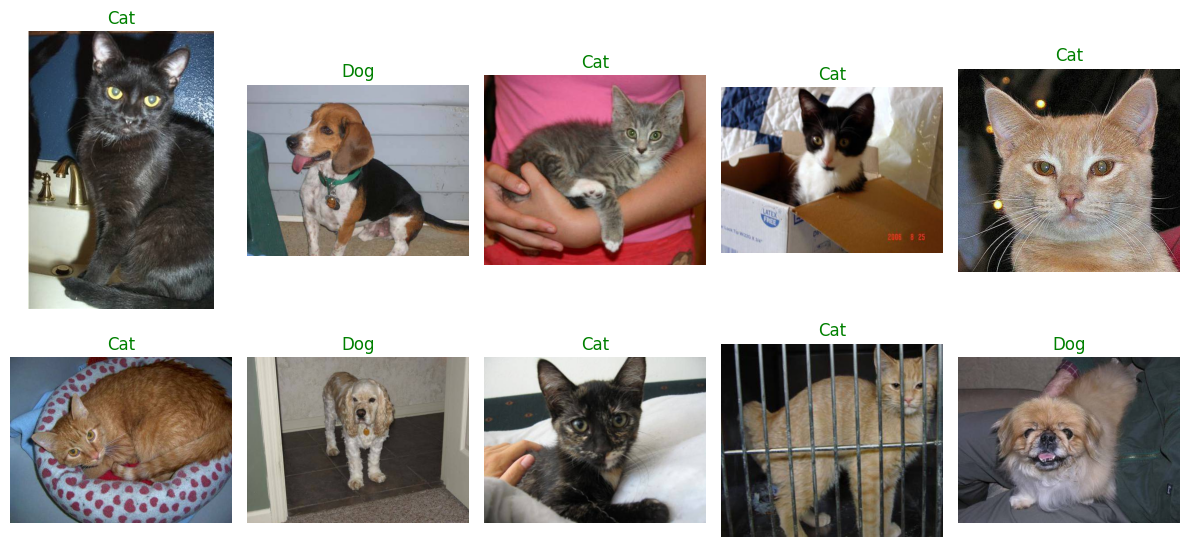

In [10]:
#테스트 데이터셋 이미지를 출력
display_image_grid(test_images_filepaths)

➡ 기본적인 데이터셋 준비 완료, 모델 학습을 위한 단계 시작

먼저 데이터셋에 학습할 데이터의 경로를 정의하고 그 경로에서 데이터를 읽어 옴
* 데이터셋 크기가 클 수 있으므로 `__init__`에서 전체 데이터를 읽어오는 것이 아니라 경로만 저장해두고, `__getitem__` 메서드에서 이미지를 읽어 옴, 즉 데이터를 어디서 가져올지 결정
* 이후 데이터로더에서 데이터셋의 데이터를 메모리로 불러오는데, 한꺼번에 전체 데이터를 불러오는 것이 아니라 배치 크기만큼 분할하여 가져옴

`DogvsCatDataset()` 클래스에서 데이터를 불러오는 방법을 정의
* 이번 예제의 목적은 다수의 개와 고양이 이미지가 포하된 데이터에서 이들을 예측하는 것이므로 레이블(정답) 이미지에서 고양이와 개가 포함될 확률을 코드로 구현

In [11]:
#이미지 데이터셋 클래스 정의
class DogvsCatDataset(Dataset):
    def __init__(self, file_list, transform=None, phase='train'):       #데이터셋의 전처리(데이터 변형 적용)
        self.file_list = file_list
        self.transform = transform      #DogvsCatDataset 클래스를 호출할 때 transform에 대한 매개변수를 받아옴
        self.phase = phase      #'train' 적용

    def __len__(self):      #images_filepaths 데이터셋의 전체 길이를 반환
        return len(self.file_list)

    def __getitem__(self, idx):     #데이터셋에서 데이터를 가져오는 부분으로 결과는 텐서 형태가 됨
        img_path = self.file_list[idx]
        img = Image.open(img_path)      #img_path 위치에서 이미지 데이터들을 가져옴
        img_transformed = self.transform(img, self.phase)       #이미지에 'train' 전처리를 적용
        label = img_path.split('/')[-1].split('.')[0]       #①
        if label == 'dog':
            label = 1
        elif label == 'cat':
            label = 0
        return img_transformed, label

↪ ① 이미지 데이터에 대한 레이블 값(dog, cat)을 가져옴
* `img_path`: 이미지가 위치한 전체 경로를 보여줌
* 이때 이미지 데이터의 레이블을 가져오려면 경로의 '/'와 '.'을 제거해야 하므로 다음을 사용
* `img_path.split('/)[-1]`: 이미지의 전체 경로에서 '/'을 제거
* `split('.')[0]`: `img_path.split('/)[-1]`을 통해 얻은 결과에서 '.'을 제거, 분리된 값들에서 첫번째 값을 가져옴

In [12]:
#변수 값 정의
size =224
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)
batch_size = 32

In [13]:
#이미지 데이터셋 정의
train_dataset = DogvsCatDataset(train_images_filepaths, transform=ImageTransform(size,
                                mean, std), phase='train')      #훈련 이미지에 train_transforms를 적용
val_dataset = DogvsCatDataset(val_images_filepaths, transform=ImageTransform(size,
                              mean, std), phase='val')      #검증 이미지에 test_transforms를 적용
index = 0
print(train_dataset.__getitem__(index)[0].size())       #훈련 데이터(train_Dataset.__getitem__[0][0])의 크기(size()) 출력
print(train_dataset.__getitem__(index)[1])      #훈련 데이터의 레이블 출력

torch.Size([3, 224, 224])
0


↪ 이미지는 컬러 상태에서 224x224 크기를 가지며 레이블이 0으로 출력됨

즉, 훈련 데이터셋의 레이블(`train_dataset.__getitem__(index)[1]`)이 0 값을 갖기 때문에 '고양이'라는 이미지가 포함되어 있다는 것 유추해볼 수 있음

In [14]:
#데이터로더 정의
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)       #①
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)
dataloader_dict = {'train': train_dataloader, 'val': val_dataloader}        #훈련 데이터셋과 검증 데이터셋을 합쳐서 표현

batch_iterator = iter(train_dataloader)
inputs, label = next(batch_iterator)
print(inputs.size())
print(label)

torch.Size([32, 3, 224, 224])
tensor([0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1,
        0, 1, 0, 1, 1, 1, 0, 1])


↪ ① 파이토치의 데이터로더는 배치 관리를 담당, 한 번에 모든 데이터를 불러오면 메모리에 부담을 줄 수 있기 때문에 데이터를 그룹으로 쪼개서 조금씩 불러옴
* 첫 번째 파라미터: 데이터를 불러오기 위한 데이터셋
* `batch_size`: 한 번에 메모리로 불러올 데이터 크기
* `shuffle`: 메모리로 데이터를 가져올 때 임의로 섞어서 가져오도록 함

In [15]:
#모델의 네트워크 클래스
class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        self.cnn1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=5, stride=1,
                            padding=0)      #2D 합성곱층이 적용. 이때 입력 형때는 (3, 224, 224)가 되며 출력 형태는 (weight-kernel_size+1)/stride에 따라 (16, 220,220)
        self.relu1 = nn.ReLU()      #ReLU 활성화 함수
        self.maxpool1= nn.MaxPool2d(kernel_size=2)      #최대 풀링이 적용. 적용 이후 출력 형태는 220/2가 되어 (16, 110,110)
        self.cnn2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5,
                            stride=1, padding=0)      #또다시 2D 합성곱층이 적용되며 출력 형태는 (32, 106, 106)
        self.relu2 = nn.ReLU()
        self.maxpool2 = nn.MaxPool2d(kernel_size=2)     #최대 풀링이 적용되며 출력 형태는 (32, 53, 53)

        self.fc1 = nn.Linear(32*53*53, 512)
        self.relu5 = nn.ReLU()
        self.fc2 = nn.Linear(512, 2)
        self.output = nn.Softmax(dim=1)

    def forward(self, x):
        out =self.cnn1(x)
        out = self.relu1(out)
        out = self.maxpool1(out)
        out= self.cnn2(out)
        out = self.relu2(out)
        out =self.maxpool2(out)
        out = out.view(out.size(0), -1)     #완전연결층에 데이터를 전달하기 위해 데이터 형태를 1차원으로 바꿈
        out = self.fc1(out)
        out = self.fc2(out)
        out = self.output(out)
        return out


In [16]:
#모델 객체 생성
model = LeNet()
print(model)

LeNet(
  (cnn1): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1))
  (relu1): ReLU()
  (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (cnn2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
  (relu2): ReLU()
  (maxpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=89888, out_features=512, bias=True)
  (relu5): ReLU()
  (fc2): Linear(in_features=512, out_features=2, bias=True)
  (output): Softmax(dim=1)
)


↪ 출력 결과가 한 눈에 들어오지 않는다면 torchsummary 라이브러리 사용해 볼 수 있음

torchsummary는 케라스와 같은 형태로 모델을 출력해볼 수 있는 라이브러리

In [17]:
!pip install torchsummary

In [18]:
#torchsummary 라이브러리를 이용한 모델의 네트워크 구조 확인
from torchsummary import summary
summary(model, input_size=(3, 224, 224))        #①

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 220, 220]           1,216
              ReLU-2         [-1, 16, 220, 220]               0
         MaxPool2d-3         [-1, 16, 110, 110]               0
            Conv2d-4         [-1, 32, 106, 106]          12,832
              ReLU-5         [-1, 32, 106, 106]               0
         MaxPool2d-6           [-1, 32, 53, 53]               0
            Linear-7                  [-1, 512]      46,023,168
            Linear-8                    [-1, 2]           1,026
           Softmax-9                    [-1, 2]               0
Total params: 46,038,242
Trainable params: 46,038,242
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.57
Forward/backward pass size (MB): 19.47
Params size (MB): 175.62
Estimated Total Size (MB): 195.67
--------------------------------

↪ ① summary를 통해 모델의 네트워크 관련 정보를 확인할 수 있음
* 첫 번째 파라미터: 모델의 네트워크
* 두 번째 파라미터: 입력 값으로 (채널, 너비, 높이)가 됨

In [19]:
#학습 가능한 파라미터 수 확인
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'The model has {count_parameters(model):,} trainable parameters')

The model has 46,038,242 trainable parameters


↪ 46,038,242개의 파라미터 학습해야 함 확인 가능

많은 파라미터를 학습해야 하기 때문에 추후 데이터를 모델에 적용했을 때 긴 시간이 걸릴 것 예상할 수 있으므로 일부 이미지만 예제에서 사용

In [20]:
#옵티마이저와 손실 함수 정의
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)       #①
criterion = nn.CrossEntropyLoss()

↪ ① 경사 하강법으로 모멘텀 SGD를 사용하도록 함
* 모멘텀 SGD는 SGD에 관성이 추가된 것으로 매번 기울기를 구하지만 가중치를 수정하기 전에 이전 수정 방향(+,-)을 참고하여 같은 방향으로 일정한 비율만 수정되게 하는 방법
    * 첫 번쨰 파라미터: 경사 하강법을 통해 궁극적으로 업데이트하고자 하는 파라미터는 가중치(weight)와 바이어서(bias)
    * `lr(learning rate)`: 가중치를 변경할 때 얼마나 크게 변경할지 결정
    * `momentum`: SGD를 적절한 방향으로 가속화하며 흔들림(진동)을 줄여주는 매개변수

In [21]:
#모델의 파라미터와 손실함수를 CPU에 할당
model = model.to(device)
criterion = criterion.to(device)

In [22]:
#모델 학습 함수 정의
def train_model(model, dataloader_dict, critierion, optimizer, num_epoch):
    since = time.time()
    best_acc = 0.0

    for epoch in range(num_epoch):   #epoch를 10으로 설정했으므로 10회 반복
        print('Epoch {}/{}'.format(epoch+1, num_epoch))
        print('-' * 20)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()       #모델을 학습시키겠다는 의미
            else:
                model.eval()

            epoch_loss = 0.0
            epoch_corrects = 0

            for inputs, labels, in tqdm(dataloader_dict[phase]):   #여기서 dataloader_dict는 훈련 데이터셋(train_loader)을 의미
                inputs = inputs.to(device)        #훈련 데이터셋을 CPU에 할당
                labels = labels.to(device)
                optimizer.zero_grad()   #역전파 단계를 실행하기 전에 기울기를 0으로 초기화

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)     #손실 함수를 이용한 오차 계산

                    if phase == 'train':
                        loss.backward()   #모델의 학습 가능한 모든 파라미터에 대해 기울기를 계산
                        optimizer.step()        #optimizer의 step 함수를 호출하면 파라미터를 갱신

                epoch_loss += loss.item() * inputs.size(0)    #①
                epoch_corrects += torch.sum(preds == labels.data)   #정답과 예측이 일치하면 그것의 합계를 epoch_corrects에 저장

            epoch_loss = epoch_loss / len(dataloader_dict[phase].dataset)    #최종 오차 계산(오차를 데이터셋의 길이(개수)로 나누어서 계산)
            epoch_acc = epoch_corrects.double() / len(dataloader_dict[phase].dataset)    #최종 정확도(epoch_corrects를 데이터셋의 길이(개수)로 나누어서 계산)

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = model.state_dict()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:4f}'.format(best_acc))
    return model

↪ ① 오차와 입력을 곱하는 이유
* 손실 함수의 `reduction`이라는 파라미터를 이해

손실 함수를 정의할 때 다음과 같이 지정할 수 있었음
`criterion = nn.CrossEntropyLoss(reduction='mean')`
* `reduction`을 따로 명시하지 않았던 이유는 기본값을 그대로 사용하기 때문
* `reduction` 파라미터의 기본값은 '`mean`'으로, '`mean`'은 정답과 예측 값의 오차를 구한 후 그 값들의 평균을 반환
* 즉, 손실 함수 특성상 전체 오차를 배치 크기로 나눔으로써 평균을 반환하기 때문에 `epoch_loss`를 계산하는 동안 `loss.item()`과 `input.size(0)`을 곱해줌

In [23]:
#모델 학습
import time

num_epoch = 10
model = train_model(model, dataloader_dict, criterion, optimizer, num_epoch)

Epoch 1/10
--------------------


/tmp/ipython-input-1032811463.py:19: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for inputs, labels, in tqdm(dataloader_dict[phase]):   #여기서 dataloader_dict는 훈련 데이터셋(train_loader)을 의미


  0%|          | 0/13 [00:00<?, ?it/s]

train Loss: 0.6959 Acc: 0.5175


  0%|          | 0/3 [00:00<?, ?it/s]

...

val Loss: 0.6805 Acc: 0.5761
Epoch 10/10
--------------------


  0%|          | 0/13 [00:00<?, ?it/s]

train Loss: 0.6454 Acc: 0.6475


  0%|          | 0/3 [00:00<?, ?it/s]

val Loss: 0.6720 Acc: 0.6087
Training complete in 5m 45s
Best val Acc: 0.608696


↪ 검증 데이터셋을 이용한 모델 학습 결과 최고 60%의 정확도 보임

테스트 데이터셋을 모델에 적용해 적확도를 즉정

측정 결과는 데이터 프레임에 담아 둔 후 CSV 파일로 저장

테스트 용도의 데이터셋 이용하므로 `model.eval()` 사용

In [24]:
#모델 테스트를 위한 함수 정의
import pandas as pd

id_list = []
pred_list = []
_id = 0
with torch.no_grad():       #역전파 중 텐서들에 대한 편화도를 계산할 필요가 없음을 나타내는 것으로, 훈련 데이터셋의 모델 학습과 가장 큰 차이점
    for test_path in tqdm(test_images_filepaths):       #테스트 데이터셋 이용
        img = Image.open(test_path)
        _id = test_path.split('/')[-1].split('.')[1]
        transform = ImageTransform(size, mean, std)
        img = transform(img, phase='val')       #테스트 데이터셋 전처리 적용
        img = img.unsqueeze(0)      #①
        img = img.to(device)

        model.eval()
        outputs = model(img)
        preds = F.softmax(outputs, dim=1)[:, 1].tolist()        #②
        id_list.append(_id)
        pred_list.append(preds[0])

res = pd.DataFrame({
    'id': id_list,
    'label': pred_list
})      #테스트 데이터셋의 예측 결과인 id와 레이블을 데이터 프레임에 저장

res.sort_values(by='id', inplace=True)
res.reset_index(drop=True, inplace=True)

res.to_csv('/content/drive/MyDrive/Euron_9기DL/data/LeNet', index=False)     #데이터 프레임을 CSV 파일로 저장

/tmp/ipython-input-1051990688.py:8: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for test_path in tqdm(test_images_filepaths):       #테스트 데이터셋 이용


  0%|          | 0/10 [00:00<?, ?it/s]

↪ ① `torch.unsqueeze`은 텐서에 차원을 추가할 때 사용, `(0)`은 차원이 추가될 위치를 의미
* 형태가 (3)인 텐서의 0 위치에 차원을 추가하면 형태가 (1,3)이 되어 행 한 개와 열 세 개의 구조를 갖는 텐서가 만들어짐
* 형태가 (2,2)인 2D 텐서가 있을 때 0 위치에 차원을 추가하면 텐서 모양이 (1,2,2)가 됨, 이는 하나의 채널, 행 두 개와 열 두 개를 의미
* 1 위치에 차원을 추가하면 (2,1,2)의 형태가 되므로 채널 두 개, 행 한 개, 열 두 개가 됨
* 2 위치에 차원을 추가하면 텐서는 (2,2,1)의 형태가 되어 채널 두 개, 행 두 개, 열 한개가 됨

② 소프트맥스는 지정된 차원을 따라 텐서의 요소(텐서의 개별 값)가 (0,1) 범위에 있고 합계가 1이 되도록 크기를 다시 조정
* `outputs`에 `softmax`를 적용하여 각 해으이 합이 1이 되도록 함
* 위의 값 중 모든 행(:)에서 두 번째 칼럼(1번째 인덱스)을 가져옴

In [25]:
#테스트 데이터셋의 예측 결과 호출
res.head(10)

,id,label
0,109,0.450474
1,145,0.381985
2,15,0.597700
3,162,0.545331
4,167,0.504879
5,200,0.481635
6,210,0.602609
7,211,0.562151
8,213,0.473419
9,224,0.568686


↪ 예측 결과 레이블이 0.5보다 크면 개를, 작으면 고양이를 의미

In [26]:
# 테스트 데이터셋 이미지를 출력하기 위한 함수 정의
class_ = classes = {0:'cat', 1:'dog'}       #개와 고양이에 대한 클래스 정의
def display_image_grid(images_filepaths, predicted_labels=(), cols=5):
    rows = len(images_filepaths) // cols
    figure, ax = plt.subplots(nrows=rows, ncols=cols, figsize=(12, 6))
    for i, images_filepath in enumerate(images_filepaths):
        image = cv2.imread(images_filepath)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        a = random.choice(res['id'].values)     #데이터 프레임의 id라는 칼럼에서 임의로 데이터 가져옴
        label = res.loc[res['id'] == a, 'label'].values[0]
        if label > 0.5:     #레이블 값이 0.5보다 크다면 개
            label = 1
        else:       #레이블 값이 0.5보다 작다면 고양이
            label = 0
        ax.ravel()[i].imshow(image)
        ax.ravel()[i].set_title(class_[label])
        ax.ravel()[i].set_axis_off()
    plt.tight_layout()      #이미지의 여백을 조정
    plt.show()

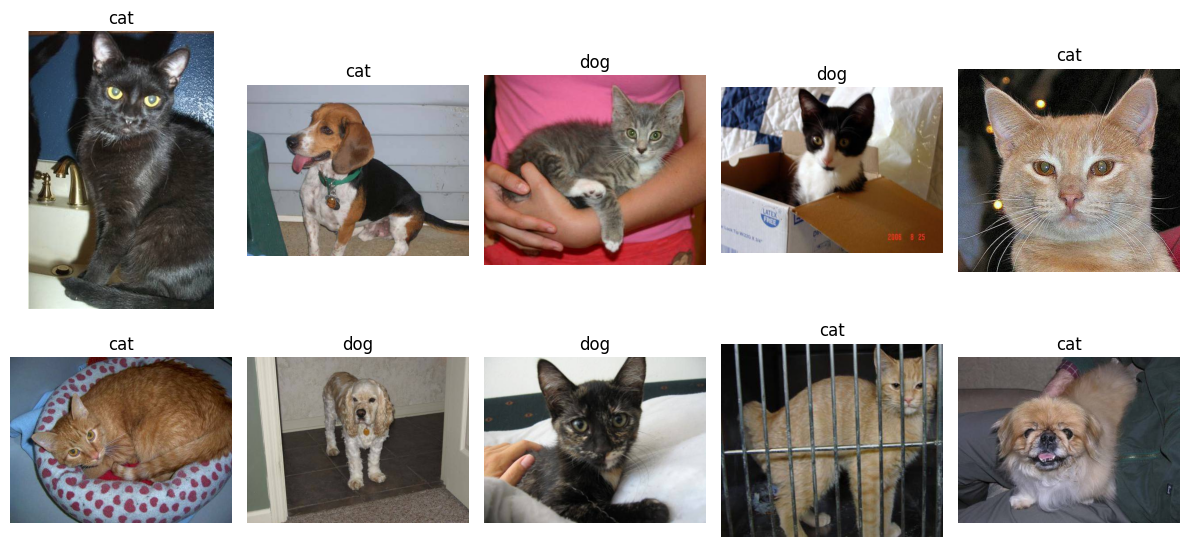

In [27]:
#테스트 데이터셋 예측 결과 이미지 출력
display_image_grid(test_images_filepaths)

###6.1.2 AlexNet

In [28]:
#필요한 라이브러리 호출
import torch
import torchvision
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torch.autograd import Variable
from torch import optim
import torch.nn as nn
import torch.nn.functional as F
import os
import cv2
import random
from PIL import Image
from tqdm import tqdm_notebook as tqdm
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [29]:
#데이터 전처리
class ImageTransform():
    def __init__(self, resize, mean, std):
        self.data_transform = {
            'train': transforms.Compose([
                transforms.RandomResizedCrop(resize, scale=(0.5,1.0)),
                transforms.RandomHorizontalFlip(),
                transforms.ToTensor(),
                transforms.Normalize(mean, std)
            ]),
            'val': transforms.Compose([
                transforms.Resize(256),
                transforms.CenterCrop(resize),
                transforms.ToTensor(),
                transforms.Normalize(mean, std)
            ])
        }

    def __call__(self, img, phase):
        return self.data_transform[phase](img)

In [30]:
#데이터를 가져와서 훈련, 검증, 테스트 용도로 분리
cat_directory = r'/content/drive/MyDrive/Euron_9기DL/data/dogs-vs-cats/Cat'
dog_directory = r'/content/drive/MyDrive/Euron_9기DL/data/dogs-vs-cats/Dog'

cat_images_filepaths = sorted([os.path.join(cat_directory, f) for f in
                               os.listdir(cat_directory)])
dog_images_filepaths = sorted([os.path.join(dog_directory, f) for f in
                               os.listdir(dog_directory)])
images_filepaths = [*cat_images_filepaths, *dog_images_filepaths]
correct_images_fliepaths = [i for i in images_filepaths if cv2.imread(i) is not None]

random.seed(42)
random.shuffle(correct_images_fliepaths)
train_images_filepaths = correct_images_fliepaths[:400]
val_images_filepaths = correct_images_fliepaths[400:-10]
test_images_filepaths = correct_images_fliepaths[-10:]
print(len(train_images_filepaths), len(val_images_filepaths), len(test_images_filepaths))

400 92 10


↪ 노트북의 성능이 좋지 않다고 가정했으므로 훈련 데이터셋을 400개로 제한함

AlexNet은 파라미터를 6000만 개 사용하는 모델

이때 충분한 데이터가 없으면 과적합이 발생하는 등 테스트 데이터에 대한 성능이 좋지 않음

성능이 좋은 결과 원한다면 충분한 데이터셋 확보하고 테스트를 진행 (캐글에서 내려받은 모든 이미지 사용, 전처리 부분에서 데이터를 많이 확장(`RandomRotation`, `RandomHorizontalFlip`등 이용))

In [31]:
#커스텀 데이터셋 정의
class DogvsCatDataset(Dataset):
    def __init__(self, file_list, transform=None, phase='train'):
        self.file_list = file_list      #이미지 데이터가 위치한 파일 경로
        self.transform = transform      #이미지 데이터 전처리
        self.phase = phase      #self.phase는 ImageTransform()에서 정의한 'train'과 'val'을 의미

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        img_path = self.file_list[idx]      #이미지 데이터의 인덱스를 가져오기
        img = Image.open(img_path)
        img_transformed = self.transform(img, self.phase)

        label = img_path.split('/')[-1].split('.')[0]       #레이블 값을 가져오기
        if label == 'dog':
            label = 1
        elif label == 'cat':
            label = 0

        return img_transformed, label       #전처리가 적용된 이미지와 레이블 반환

In [32]:
#변수에 대한 값 정의
size = 256      #AlexNet은 깊이가 깊은 네트워크를 사용하므로 이미지 크기가 256이 아니면 풀링층 때문에 크기가 계속 줄어들어 오류 발생할 수 있음
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)
batch_size = 32

In [33]:
#훈련, 검증, 테스트 데이터셋 정의
train_dataset = DogvsCatDataset(train_images_filepaths, transform=ImageTransform(size,
                                mean, std), phase='train')
val_dataset = DogvsCatDataset(val_images_filepaths, transform=ImageTransform(size,
                              mean, std), phase='val')
test_dataset = DogvsCatDataset(val_images_filepaths, transform=ImageTransform(size,
                              mean, std), phase='val')
index = 0
print(train_dataset.__getitem__(index)[0].size())
print(train_dataset.__getitem__(index)[1])

torch.Size([3, 256, 256])
0


In [34]:
#데이터셋을 메모리로 불러옴
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)
dataloader_dict = {'train': train_dataloader, 'val': val_dataloader}

batch_iterator = iter(train_dataloader)
inputs, label = next(batch_iterator)
print(inputs.size())
print(label)

torch.Size([32, 3, 256, 256])
tensor([1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 0, 1, 0, 1, 0, 0, 0])


In [35]:
#AlexNet 모델 네트워크 정의
class AlexNet(nn.Module):
    def __init__(self) -> None:
        super(AlexNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),      #①
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))     #②
        self.classifier = nn.Sequential(
            nn.Dropout(),
            nn.Linear(256*6*6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, 2),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

AlexNet 모델을 사용하기 위한 네트워크는 사전 훈련된 네트워크와 유사하게 정의

합성곱(Conv2d)+(활성화 함수(ReLU))+풀링(MaxPool2d)이 다섯 번 반복된 후 두 개의 완전연결틍과 출력층으로 구성된 네트워크

↪ ① ReLU 활성화 함수에서 `inplace`의 의미
* `inplace` 연산이랑 연산에 대한 결괏값을 새로운 변수에 저장하는 것이 아닌 기존 데이터를 대체하는 것을 의미
* 즉, 기존 값을 연산 결괏값으로 대체함으로써 기존 값들을 무시하겠다는 의미

② `nn.AdaptiveAvgPool2d`는 `nn.AvgPool2d`처럼 풀링을 위해 사용
* `AvgPool2d`에서는 풀링에 대한 커널 및 스트라이드 크기를 정의해야 동작함
* 반면 `AdaptiveAvgPool2d`는 풀링 작업이 끝날 때 필요한 출력 크기를 정의
* 즉, `nn.AvgPool2d`에서는 커널 크기, 스트라이드, 패딩을 지정했다면 `nn.AdaptiveAvgPool2d`는 출력에 대한 크기만 지정
* 따라서 `AdaptiveAvgPool2d`를 사용할 경우 출력 크기에 대한 조정이 상당히 쉬워짐
    * 입력 크기에 변동이 있고 CNN 위쪽에 완전연결층을 사용하는 경우 유용

In [36]:
#model 객체 생성
model = AlexNet()
model.to(device)

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [37]:
#옵티마이저 및 손실함수 정의
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
criterion = nn.CrossEntropyLoss()

In [38]:
#모델 네트워크 구조 확인
from torchsummary import summary
summary(model, input_size=(3, 256, 256))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 63, 63]          23,296
              ReLU-2           [-1, 64, 63, 63]               0
         MaxPool2d-3           [-1, 64, 31, 31]               0
            Conv2d-4          [-1, 192, 31, 31]         307,392
              ReLU-5          [-1, 192, 31, 31]               0
         MaxPool2d-6          [-1, 192, 15, 15]               0
            Conv2d-7          [-1, 384, 15, 15]         663,936
              ReLU-8          [-1, 384, 15, 15]               0
            Conv2d-9          [-1, 256, 15, 15]         884,992
             ReLU-10          [-1, 256, 15, 15]               0
           Conv2d-11          [-1, 256, 15, 15]         590,080
             ReLU-12          [-1, 256, 15, 15]               0
        MaxPool2d-13            [-1, 256, 7, 7]               0
AdaptiveAvgPool2d-14            [-1, 25

In [39]:
#모델 학습 함수 정의
def train_model(model, dataloader_dict, critierion, optimizer, num_epoch):

    since = time.time()
    best_acc = 0.0

    for epoch in range(num_epoch):
        print('Epoch {}/{}'.format(epoch+1, num_epoch))
        print('-' * 20)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            epoch_loss = 0.0
            epoch_corrects = 0

            for inputs, labels, in tqdm(dataloader_dict[phase]):
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                    epoch_loss += loss.item() * inputs.size(0)
                    epoch_corrects += torch.sum(preds == labels.data)

            epoch_loss = epoch_loss / len(dataloader_dict[phase].dataset)
            epoch_acc = epoch_corrects.double() / len(dataloader_dict[phase].dataset)

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
    return model

In [40]:
#모델 학습
import time
num_epoch = 10
model = train_model(model, dataloader_dict, criterion, optimizer, num_epoch)

Epoch 1/10
--------------------


/tmp/ipython-input-3954860312.py:20: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for inputs, labels, in tqdm(dataloader_dict[phase]):


  0%|          | 0/13 [00:00<?, ?it/s]

train Loss: 0.6933 Acc: 0.4850


  0%|          | 0/3 [00:00<?, ?it/s]

...

val Loss: 0.6927 Acc: 0.5435
Epoch 10/10
--------------------


  0%|          | 0/13 [00:00<?, ?it/s]

train Loss: 0.6927 Acc: 0.5300


  0%|          | 0/3 [00:00<?, ?it/s]

val Loss: 0.6927 Acc: 0.5543
Training complete in 9m 6s


In [41]:
#모델을 이용한 예측
import pandas as pd
id_list = []
pred_list = []
_id = 0
with torch.no_grad():
    for test_path in tqdm(test_images_filepaths):       #테스트 이미지 데이터 이용
        img = Image.open(test_path)
        _id = test_path.split('/')[-1].split('.')[1]        #이미지 데이터의 번호 가져오기(예를 들어 dog.113.jpg라는 이미지 이름에서 113 가져오기)
        transform = ImageTransform(size, mean, std)
        img = transform(img, phase='val')       #테스트 데이터에 검증용 전처리 적용
        img = img.unsqueeze(0)
        img = img.to(device)

        model.eval()
        outputs = model(img)
        preds = F.softmax(outputs, dim=1)[:, 1].tolist()

        id_list.append(_id)
        pred_list.append(preds[0])

res = pd.DataFrame({
    'id': id_list,
    'label': pred_list
})      #데이터 프레임에 이미지의 id(번호)와 레이블 저장

res.to_csv('/content/drive/MyDrive/Euron_9기DL/data/alexnet.csv', index=False)     #이미지의 id와 레이블을 alexnet.csv파일에 저장

/tmp/ipython-input-1443836803.py:7: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for test_path in tqdm(test_images_filepaths):       #테스트 이미지 데이터 이용


  0%|          | 0/10 [00:00<?, ?it/s]

In [42]:
#데이터 프레임 결과 확인
res.head(10)

,id,label
0,145,0.501107
1,211,0.501993
2,162,0.501011
3,200,0.504219
4,210,0.502357
5,224,0.500150
6,213,0.501159
7,109,0.503510
8,15,0.501490
9,167,0.500544


↪ `label` 값이 0.5보다 크면 개, 작으면 고양이로 예측했음을 의미

In [43]:
#예측 결과를 시각적으로 표현하기 위한 함수 정의
class_ = classes = {0:'cat', 1:'dog'}
def display_image_grid(images_filepaths, predicted_labels=(), cols=5):
    rows = len(images_filepaths) // cols
    figure, ax = plt.subplots(nrows=rows, ncols=cols, figsize=(12, 6))
    for i, images_filepath in enumerate(images_filepaths):
        image = cv2.imread(images_filepath)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        a = random.choice(res['id'].values)
        label = res.loc[res['id'] == a, 'label'].values[0]
        if label > 0.5:
            label = 1
        else:
            label = 0
        ax.ravel()[i].imshow(image)
        ax.ravel()[i].set_title(class_[label])
        ax.ravel()[i].set_axis_off()
    plt.tight_layout()
    plt.show()

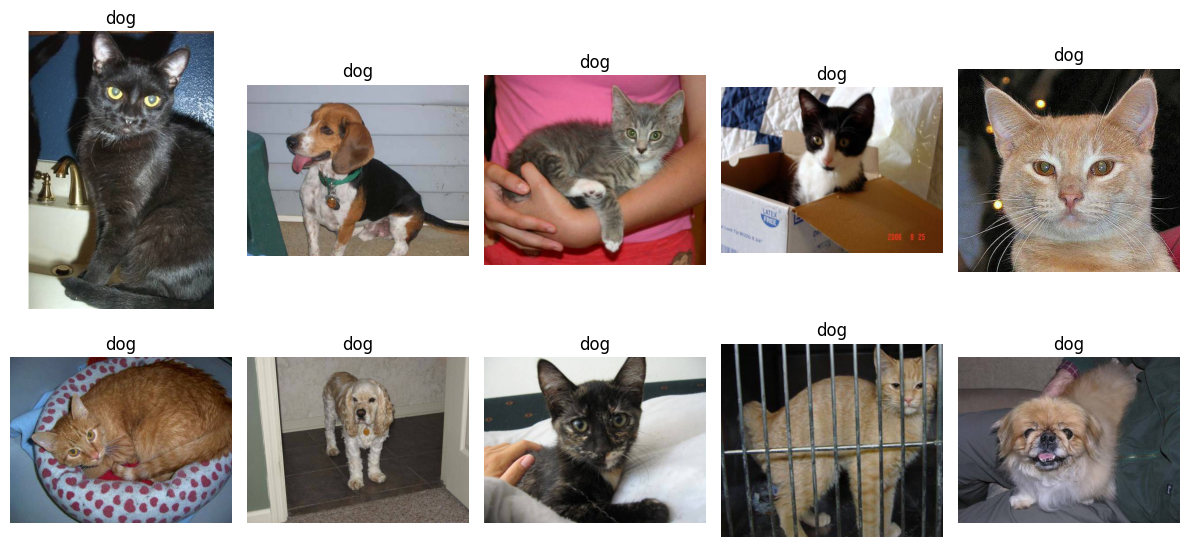

In [44]:
#예측 결과에 대해 이미지와 함께 출력
import matplotlib.pyplot as plt

display_image_grid(test_images_filepaths)

###6.1.3 VGGNet

VGGNet 중에서 가장 간단한 VGG11을 파이토치로 구현

In [2]:
#필요한 라이브러리 호출
import copy     #①
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as Dataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

↪ ① 객체 복사를 위해 사용
* 객체 복사는 크게 얕은 복사(shallow copy)와 깊은 복사(deep copy)로 나뉨

In [46]:
#단순한 객체 복사 예시 코드
original = [1, 2, 3]        #original이라는 변수에 [1, 2, 3] 저장
copy_o = original       #copy_o에 original 복사(shallow copy)
print(copy_o)
copy_o[2] = 10       #copy_o의 3을 10으로 값을 변경
print(copy_o)
print(original)

[1, 2, 3]
[1, 2, 10]
[1, 2, 10]


↪ 원래 값인 `original`의 3도 10으로 바뀜

In [47]:
#얕은 복사 예시 코드
import copy

original = [[1, 2], 3]
copy_o = copy.copy(original)        #original 값을 copy_o에 얕은 복사(copy.copy())
print(copy_o)
copy_o[0] = 100     #copy_o의 [1,2] 값을 100으로 변경
print(copy_o)
print(original)

append = copy.copy(original)
append[0].append(4)     #첫 번째 리스트([1,2])에 4를 추가
print(append)
print(original)

[[1, 2], 3]
[100, 3]
[[1, 2], 3]
[[1, 2, 4], 3]
[[1, 2, 4], 3]


↪ [1,2] 값을 100으로 변경했더니 `copy_o`만 바뀜

[1,2]에 4를 추가했더니 `original`과 `copy_o` 모두 반영

In [48]:
#깊은 복사 예시 코드
import copy

original = [[1, 2], 3]
copy_o= copy.deepcopy(original)     #original 값을 copy_o에 깊은 복사(copy.deepcopy())
print(copy_o)
copy_o[0] = 100     #copy_o의 [1,2] 값을 100으로 변경
print(copy_o)
print(original)

append= copy.deepcopy(original)
append[0].append(4)     #첫 번째 리스트([1, 2])에 4를 추가
print(append)
print(original)

[[1, 2], 3]
[100, 3]
[[1, 2], 3]
[[1, 2, 4], 3]
[[1, 2], 3]


↪ [1,2] 값을 100으로 변경했더니 `copy_o`만 바뀐 것은 동일

[1,2]에 4를 추가했더니 `copy_o`는 변경되었지만 `original`은 그대로



---



In [3]:
#VGG 모델 정의
class VGG(nn.Module):
    def __init__(self, features, output_dim):
        super().__init__()
        self. features = features       #VGG 모델에 대한 매개변수에서 받아 온 features 값을 self.features에 넣어줌
        self.avgpool = nn.AdaptiveAvgPool2d(7)
        self.classifier = nn.Sequential(
            nn.Linear(512*7*7, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, output_dim)
        )       #완전연결층과 출력층 정의

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        h = x.view(x.shape[0], -1)
        x = self.classifier(h)
        return x, h

In [4]:
#모델 유형 정의
vgg11_config = [64, 'M', 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M']     #8(합성곱충)+3(풀링충)=11(전체 계층)=VGG11

vgg13_config = [64, 64, 'M', 128, 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512,
                'M']       #10(합성곱충)+3(풀링충)=13(전체 계층)=VGG13

vgg16_config = [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 'M', 512, 512, 512, 'M',
                512, 512, 512, 'M']     #13(합성곱충)+3(풀링층)=16(전체 계충)=VGG16

vgg19_config = [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 256, 'M', 512, 512, 512,
                512, 'M', 512, 512, 512, 512, 'M']      #16(합성곱충)+3(풀링충)=19(전체 계층)=VGG19

↪ 숫자(output channel, 출력 채널)는 Conv2d를 수행하라는 의미

출력 채널이 다음 계층의 입력 채널이 됨

M은 최대 풀링을 수행하라는 의미

In [5]:
#VGG 계층 정의
def get_vgg_layers(config, batch_norm):
    layers = []
    in_channels = 3

    for c in config:        #vgg11_config 값들을 가져옵니다.
        assert c == 'M' or isinstance(c, int)       #①
        if c == 'M':        #불러온 값이 'M'이면 최대 풀링(MaxPool2d)을 적용
            layers += [nn.MaxPool2d(kernel_size=2)]
        else:       #불러온 값이 숫자이면 합성곱(Conv2d) 적용
            conv2d = nn.Conv2d(in_channels, c, kernel_size=3, padding=1)
            if batch_norm:      #배치 정규화(batch normalization)를 적용할지에 대한 코드
                layers += [conv2d, nn.BatchNorm2d(c), nn.ReLU(inplace=True)]        #배치 정규화가 적용될 경우 배치 정규화+ReLU 적용
            else:
                layers +=[conv2d, nn.ReLU(inplace=True)]        #배치 정규화가 적용되지 않을 경우 ReLU만 적용
            in_channels = c

    return nn. Sequential(*layers)      #네트워크의 모든 계층을 반환


↪ ① 조건문을 정의
* 가정 설정문이라고 불리는 `assert`는 뒤의 조건이 `True`가 아니면 에러 발생시킴, 따라서 c == 'M'이 아니면 오류가 발생
* `isinstance`는 주어진 조건이 `True`인지 판단

In [52]:
#assert 예시 코드
a = 1
assert a == 11

AssertionError: 

In [53]:
#isinstance 예시 코드
print(isinstance(1, int))       #1이 integer인지 판단
print(isinstance(1.2, int))     #1.2이 integer인지 판단
print(isinstance('deep learning', str))     #deep learning이 string인지 판단

True
False
True


↪ 따라서 `assert c == 'M' or isinstance(c, int)` 의미는 c가 'M'이 아니거나 int가 아니라면 오류가 발생함


---



In [6]:
#모델 계층 생성
vgg11_layers = get_vgg_layers(vgg11_config, batch_norm=True)        #①

↪ ① `batch_norm(Batch Normalization)`은 데이터의 평균을 0으로, 표준편차를 1로 분포시키는 것
* 각 계층에서 입력 데이터의 분포는 앞 계층에서 업데이트된 가중치에 따라 변함
* 즉, 각 계층마다 변화되는 분포는 학습 속도를 늦출 뿐만 아니라 학습도 어렵게 함
* 따라서 각 계층의 입력에 대한 분산을 평균 0, 표준편차 1로 분포시키는 것이 `batch_norm`(배치 정규화)

In [7]:
#VGG11 계층 확인
print(vgg11_layers)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU(inplace=True)
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): ReLU(inplace=True)
  (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (13): ReLU(inplace=True)
  (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, cei

↪ 배치 정규화(BatchNorm2d)가 추가된 것을 확인할 수 있음

In [8]:
#VGG11 전체에 대한 네트워크
OUTPUT_DIM = 2      #개와 고야잉 두 개의 클래스 사용
model = VGG(vgg11_layers, OUTPUT_DIM)
print(model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(ke

↪ 앞에서 정의했던 `vgg11_layers`, 완전연결층과 출력층(`(classifier): Sequential()`) 부분을 합친 것 확인할 수 있음

In [9]:
#VGG11 사전 훈련된 모델 사용
import torchvision.models as models
pretrained_model = models.vgg11_bn(pretrained=True)     #①
print(pretrained_model)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG11_BN_Weights.IMAGENET1K_V1`. You can also use `weights=VGG11_BN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(ke

↪ ① 배치 정규화가 적용된 사전 훈련된 VGG11 모델을 사용하기 위해서는 다음과 같은 파라미터 사용
* `vgg11_bn`은 VGG11 기본 모델에 배치 정규화가 적용된 모델을 사용하겠다는 의미
* `pretrained`를 `True`로 설정하면 사전 훈련된 모델을 사용(미리 학습된 파라미터 값들을 사용)하겠다는 의미


사전 훈련된 모델 호출 대신 직접 구현한 코드로 네트워크 정의하면 `My_Vgg`와 같이 새로운 config를 정의해 사용할 수 있음

In [10]:
#이미지 데이터 전처리
train_transforms = transforms.Compose([
                        transforms.Resize((256,256)),
                        transforms.RandomRotation(5),
                        transforms.RandomHorizontalFlip(0.5),
                        transforms. ToTensor(),
                        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229,
                                            0.224, 0.225])])       #①
test_transforms = transforms.Compose([
                        transforms.Resize((256,256)),
                        transforms.ToTensor(),
                        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229,
                                            0.224, 0.225])])

↪ ① 데이터 전처리에 사용되는 `transforms.Compose` 파라미터 중 새롭게 등장한 것들 소개
* `transforms.Resize`: 이미지를 주어진 크기로 재조정
* `transforms.RandomRotation`: 5도 이하로 이미지를 회전

In [11]:
#ImageFolder를 이용하여 데이터셋 불러오기
train_path = '/content/drive/MyDrive/Euron_9기DL/data/catanddog/train'       #훈련 데이터셋이 위치한 경로
test_path = '/content/drive/MyDrive/Euron_9기DL/data/catanddog/test'     #테스트 데이터셋이 위치한 경로

train_dataset = torchvision.datasets.ImageFolder(
    train_path,
    transform=train_transforms
)       #①

test_dataset = torchvision.datasets. ImageFolder(
    test_path,
    transform=test_transforms
)

print(len(train_dataset)), print(len(test_dataset))

385
98


(None, None)

↪ ① ImageFolder를 언제 사용하면 좋을지
* ImageFolder는 계층적인 폴더 구조를 가지고 있는 데이터셋을 불러올 때 사용
* train 폴더 하위에 Cat, Dog 폴더가 계층적으로 위치해 있고 이러한 구조에서 데이터셋 불러오고 싶을 때 사용

In [12]:
#훈련과 검증 데이터 분할
VALID_RATIO = 0.9
n_train_examples = int(len(train_dataset)*VALID_RATIO)      #전체 훈련 데이터 중 90%를 훈련 데이터셋으로 사용
n_valid_examples = len(train_dataset)-n_train_examples      #전체 훈련 데이터 중 10$를 검증 데이터셋으로 사용

train_data, valid_data = data.random_split(train_dataset,
                                            [n_train_examples, n_valid_examples])       #①

↪ ① `random_split()`은 훈련과 검증 데이터셋을 나누는 용도로 사용
* 데이터가 데이터로더로 넘어간 이후에는 분리가 불가능하므로 데이터셋 단꼐에서 진행해야 함
* 첫 번째 파라미터: 분할에 사용될 데이터셋
* 두 번째 파라미터: 훈련과 검증 데이터셋의 크기 지정, [훈련 데이터셋 크기, 검증 데이터셋 크기]

In [13]:
#검증 데이터 전처리
valid_data = copy.deepcopy(valid_data)
valid_data.dataset.transform = test_transforms

In [14]:
#훈련, 검증, 테스트 데이터셋 수 확인
print(f'Number of training examples: {len(train_data)}')
print(f'Number of validation examples: {len(valid_data)}')
print(f'Number of testing examples: {len(test_dataset)}')

Number of training examples: 346
Number of validation examples: 39
Number of testing examples: 98


In [15]:
#메모리로 데이터 불러오기
BATCH_SIZE = 64
train_iterator = data.DataLoader(train_data,
                                 shuffle=True,
                                 batch_size=BATCH_SIZE)     #훈련 데이터셋은 임의로 섞어서 가져옴

valid_iterator = data.DataLoader(valid_data,
                                 batch_size=BATCH_SIZE)

test_iterator = data. DataLoader(test_dataset,
                                 batch_size=BATCH_SIZE)



In [16]:
#옵티마이저와 손실 함수 정의
optimizer = optim. Adam(model.parameters(), lr=1e-7)
criterion = nn.CrossEntropyLoss()

model = model.to(device)
criterion = criterion.to(device)

In [17]:
#모델 정확도 측정 함수
def calculate_accuracy(y_pred, y):
    top_pred=y_pred.argmax(1, keepdim=True)
    correct = top_pred.eq(y.view_as(top_pred)).sum()        #①
    acc = correct.float() / y.shape[0]
    return acc

↪ ① 예측이 정답과 일치하는 경우 그 개수의 합을 `correct` 변수의 저장
* `eq`는 equal의 약자로 서로 같은지를 비교하는 표현식
* `view_as(other)`는 other의 텐서 크기를 사용하겠다는 의미
    * 즉, `view_as(other)`는 `view_as(other.size())`와 같은 의미
    * 따라서 `y.view_as(top_pred)`는 y에 대한 텐서 크기를 `top_pred`의 텐서 크기로 변경하겠다는 의미
* 합계를 구하는 것으로, 여기에서는 예측과 정답이 일치하는 것들의 개수를 합산하겠다는 의미

In [18]:
#모델 학습 함수 정의
def train(model, iterator, optimizer, criterion, device):
    epoch_loss = 0
    epoch_acc = 0

    model.train()
    for (x, y) in iterator:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        y_pred, _ = model(x)
        loss = criterion(y_pred, y)
        acc = calculate_accuracy(y_pred, y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc += acc.item()
    return epoch_loss / len(iterator), epoch_acc / len(iterator)

In [19]:
#모델 성능 측정 함수
def evaluate(model, iterator, criterion, device):
    epoch_loss = 0
    epoch_acc = 0

    model.eval()
    with torch.no_grad():
        for (x, y) in iterator:
            x = x.to(device)
            y = y.to(device)
            y_pred, _= model(x)
            loss = criterion(y_pred, y)
            acc = calculate_accuracy(y_pred, y)
            epoch_loss += loss.item()
            epoch_acc += acc.item()
    return epoch_loss / len(iterator), epoch_acc / len(iterator)

In [20]:
#학습 시간 측정 함수
import time

def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins= int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time -(elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

In [22]:
#모델 학습
EPOCHS = 5
best_valid_loss = float('inf')
for epoch in range(EPOCHS):
    start_time = time.monotonic()
    train_loss, train_acc = train(model, train_iterator, optimizer, criterion, device)      #훈련 데이터셋을 모델에 적용한 결과(오차와 정확도)를 train_loss와 train_acc에 저장
    valid_loss, valid_acc = evaluate(model, valid_iterator, criterion, device)      #검증 데이터셋을 모델에 적용한 결과(오차와 정확도)를 valid_loss와 valid_acc에 저장

    if valid_loss < best_valid_loss:        #valid_loss가 가장 작은 값을 구하고 그 상태의 모델을 VGG-model.pt 이름으로 저장
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), '/content/drive/MyDrive/Euron_9기DL/data/VGG-model.pt')

    end_time = time.monotonic()
    epoch_mins, epoch_secs = epoch_time(start_time, end_time)       #모델 훈련에 대한 시작과 종료 시간을 저장

    print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss :.3f} | Train Acc: {train_acc*100 :.2f}%')
    print(f'\t Valid. Loss: {valid_loss :.3f} | Valid. Acc: {valid_acc*100 :.2f}%')

Epoch: 01 | Epoch Time: 0m 9s
	Train Loss: 0.694 | Train Acc: 51.30%
	 Valid. Loss: 0.693 | Valid. Acc: 53.85%
Epoch: 02 | Epoch Time: 0m 10s
	Train Loss: 0.697 | Train Acc: 50.36%
	 Valid. Loss: 0.692 | Valid. Acc: 53.85%
Epoch: 03 | Epoch Time: 0m 6s
	Train Loss: 0.692 | Train Acc: 51.84%
	 Valid. Loss: 0.693 | Valid. Acc: 53.85%
Epoch: 04 | Epoch Time: 0m 17s
	Train Loss: 0.692 | Train Acc: 51.96%
	 Valid. Loss: 0.693 | Valid. Acc: 53.85%
Epoch: 05 | Epoch Time: 0m 7s
	Train Loss: 0.703 | Train Acc: 46.21%
	 Valid. Loss: 0.693 | Valid. Acc: 51.28%


↪ 성능이 좋지 않으며, 데이터셋으로 사용되는 이미지 수가 매우 적고 에포크도 매우 적게 설정됨

In [24]:
#테스트 데이터셋을 이용한 모델 성능 측정
model.load_state_dict(torch.load('/content/drive/MyDrive/Euron_9기DL/data/VGG-model.pt'))
test_loss, test_acc = evaluate(model, test_iterator, criterion, device)
print(f'Test Loss: {test_loss :.3f} | Test Acc: {test_acc*100 :.2f}%')

Test Loss: 0.691 | Test Acc: 61.72%


In [25]:
#테스트 데이터셋을 이용한 모델의 예측 확인 함수
def get_predictions(model, iterator):
    model.eval()
    images = []
    labels = []
    probs = []

    with torch.no_grad():
        for (x, y) in iterator:
            x = x.to(device)
            y_pred, _= model(x)
            y_prob = F.softmax(y_pred, dim =- 1)
            top_pred =y_prob.argmax(1, keepdim=True)        #①
            images.append(x.cpu())
            labels.append(y.cpu())
            probs.append(y_prob.cpu())

    images = torch.cat(images, dim=0)       #②
    labels = torch.cat(labels, dim=0)
    probs = torch.cat(probs, dim=0)
    return images, labels, probs

↪ ① `argmax`는 배열에서 가장 큰 값의 인덱스를 찾을 때 사용
* 첫 번쨰 파라미터: 행(axis=0) 또는 열(axis=1)을 따라 가장 큰 값의 색인을 찾음. 따라서 1은 열을 따라 가장 큰 값의 색인을 찾겠다는 의미
* `keepdim: keepdim=True`의 경우 출력 텐서를 입력과 동일한 크기로 유지하겠다는 의미

② `torch.cat`은 텐서를 연결할 때 사용

In [26]:
#torch.cat 예시 코드
import torch
x = torch.Tensor([[1, 2, 3], [2, 3, 4]])
y = torch. Tensor([[4, 5, 6], [5, 6, 7]])

print(torch.cat([x], dim=0))        #행을 기준(dim=0)으로 ×롤 이어 붙임
print('------------------')
print(torch.cat([x, y]))        #단순하게 ×와 y를 결합하라는 의미이며 출력 결과는 (4×3) 형태
print('------------------')
print(torch.cat([x,y],dim=0))       #행을 기준(dim=0)으로 x와 y를 이어 붙이면 (4×3) 텐서가 됨
print('------------------')
print(torch.cat([x, y],dim=1))      #열을 기준(dim=1)으로 x와 y를 이어 붙이면 (2×6) 텐서가 됨

tensor([[1., 2., 3.],
        [2., 3., 4.]])
------------------
tensor([[1., 2., 3.],
        [2., 3., 4.],
        [4., 5., 6.],
        [5., 6., 7.]])
------------------
tensor([[1., 2., 3.],
        [2., 3., 4.],
        [4., 5., 6.],
        [5., 6., 7.]])
------------------
tensor([[1., 2., 3., 4., 5., 6.],
        [2., 3., 4., 5., 6., 7.]])




---



In [27]:
#예측 중에서 정확하게 예측한 것을 추출
images, labels, probs = get_predictions(model, test_iterator)
pred_labels = torch.argmax(probs, 1)        #①
corrects = torch.eq(labels, pred_labels)        #예측과 정답이 같은지 비교
correct_examples = []

for image, label, prob, correct in zip(images, labels, probs, corrects):        #②
    if correct:
        correct_examples.append((image, label, prob))

correct_examples.sort(reverse=True, key=lambda x: torch.max(x[2], dim=0).values)        #③

↪ ① `max`는 최댓값을, `argmax`는 최댓값을 갖는 인덱스를 반환

In [28]:
#예시 코드
x = torch.rand(5,3)     #(5×3) 형태의 텐서 생성
print(x)

tensor([[0.8477, 0.1584, 0.0438],
        [0.4857, 0.6927, 0.3236],
        [0.2528, 0.3807, 0.2819],
        [0.1157, 0.8517, 0.1030],
        [0.1900, 0.5494, 0.2181]])


In [30]:
print(torch.max(x))     #max의 반환값 알아보기
print('------------')
print(torch.argmax(x))      #argmax의 반환값 알아보기

tensor(0.8517)
------------
tensor(10)


↪ 다음 결과와 같이 `max`는 텐서의 요소 중 가장 높은 값을, `argmax`는 그 인덱스를 반환


---



↪ ② `zip()`은 여러 개의 리스트(혹은 튜플)를 합쳐서 새로운 튜플 타입으로 반환

In [31]:
#예시 코드
a = [1, 2, 3]
b = ['a', 'b', 'c']

for x, y in zip(a, b):      #a, b가 리스트로 구성되었기 때문에 for 문을 통해 반복하여 값을 가져옴
    print(x, y)

1 a
2 b
3 c




---



↪ ③ 데이터를 정렬하기 위해 `sort()` 메서트를 사용
* `reverse`: 내림차순으로 정렬

In [32]:
#예시 코드
x = [1, 7, 3, 9]        #정렬되어 있지 않은 ×라는 텐서 생성
x.sort(reverse=True)      #×에 내림차순 적용
print('x:', x)

x: [9, 7, 3, 1]




---



* `key`: 데이터를 정렬할 때 `key` 값을 가지고 정렬하며 기본값은 오름차순
    * 여기서 사용되는 람다는 일종의 함수
    * 일반적으로 함수는 `def 함수명()` 처럼 사용하지만 람다 함수는 함수명 없이도 사용가능
    * 함다 함수는 정의와 동시에 사용할 수 있지만 함수명이 없고, 저장된 변수가 없기 때문에 재사용은 불가능

In [33]:
#예시 코드
y = lambda x: x + 10
y(1)

11



---



* `torch.max(x[2], dim=0)` 의미

In [34]:
x= torch.randn([4, 4])      #(4×4) 크기를 갖는 임의의 텐서 생성
print(x)

max_elements, max_idxs= torch.max(x, dim=0)     #torch.max 값을 가지고 오되 dim=0(행을 기준)으로 최댓값을 가져옴

print(max_elements)
print(max_idxs)

tensor([[-0.1486, -0.7258,  0.8849,  1.4752],
        [-0.5571, -1.3841,  1.1984, -1.6647],
        [ 0.5021,  0.3433, -0.5400, -0.6301],
        [-1.2631, -0.3151, -0.4986,  0.3684]])
tensor([0.5021, 0.3433, 1.1984, 1.4752])
tensor([2, 2, 1, 0])


In [35]:
#이미지 출력을 위한 전처리
def normalize_image(image):
    image_min = image.min()
    image_max = image.max()
    image.clamp_(min=image_min, max=image_max)      #torch.clamp는 주어진 최소(min), 최대(max)의 범주에 이미지가 위치하도록 함
    image.add_(-image_min).div_(image_max-image_min+1e-5)       #①
    return image

↪ ① `torch.add`는 더하라는 메서드

In [36]:
#torch.add와 torch.add_ 의 차이
x = torch.tensor([1, 2])
y = x.add(10)       #torch.add 적용
print(y)
print(x is y)
print('------------')
y =x.add_(10)       #torch.add_ 적용
print(y)
print(x is y)

tensor([11, 12])
False
------------
tensor([11, 12])
True


↪ 결과는 같지만 x가 y와 같은지 물었을 때에는 다른 값을 출력

즉 `torch.add`의 결과는 새로운 메모리 공간이 할당되어 저장되기 때문에 x와 y가 같은지 물었을 때 False라는 결과를 출력한 반면, `torch.add_`는 새로운 공간 할당 없이 기존 메모리에 위치한 값을 대체함
* 메서드에 _ 표시가 있다면 기존의 메모리 공간에 있는 값을 새로운 값으로 대체하겠다는 의미


---



In [41]:
#모델이 정확하게 예측한 이미지 출력 함수
def plot_most_correct(correct, classes, n_images, normalize=True):
    rows = int(np.sqrt(n_images))       #np.sqrt는 제곱근을 계산(0.5를 거듭제곱)
    cols = int(np.sqrt(n_images))
    fig = plt.figure(figsize=(25,20))
    for i in range(rows*cols):
        ax = fig.add_subplot(rows, cols, i+1)       #출력하려는 그래프 개수만큼 subplot을 만듭니다.
        image, true_label, probs = correct[i]
        image = image.permute(1, 2, 0)      #①
        true_prob = probs[true_label]
        correct_prob, correct_label = torch.max(probs, dim=0)
        true_class = classes[true_label]
        correct_class = classes[correct_label]

        if normalize:       #본래 이미지대로 출력하기 위해 normalize_image 함수 호출
            image = normalize_image(image)

        ax.imshow(image.cpu().numpy())
        ax.set_title(f'true label: {true_class} ({true_prob :.3f})\n' \
                     f'pred label: {correct_class} ({correct_prob :.3f})')
        ax.axis('off')

    fig.subplots_adjust(hspace=0.4)

↪ ① `image.permute`는 축을 변경할 때 사용

In [38]:
#예시 코드
x = torch.tensor([[1, 2, 3], [4, 5, 6]])
print(x)
x.permute(1, 0)     #차원(축) O과 1을 바꿉니다.

tensor([[1, 2, 3],
        [4, 5, 6]])


tensor([[1, 4],
        [2, 5],
        [3, 6]])



---



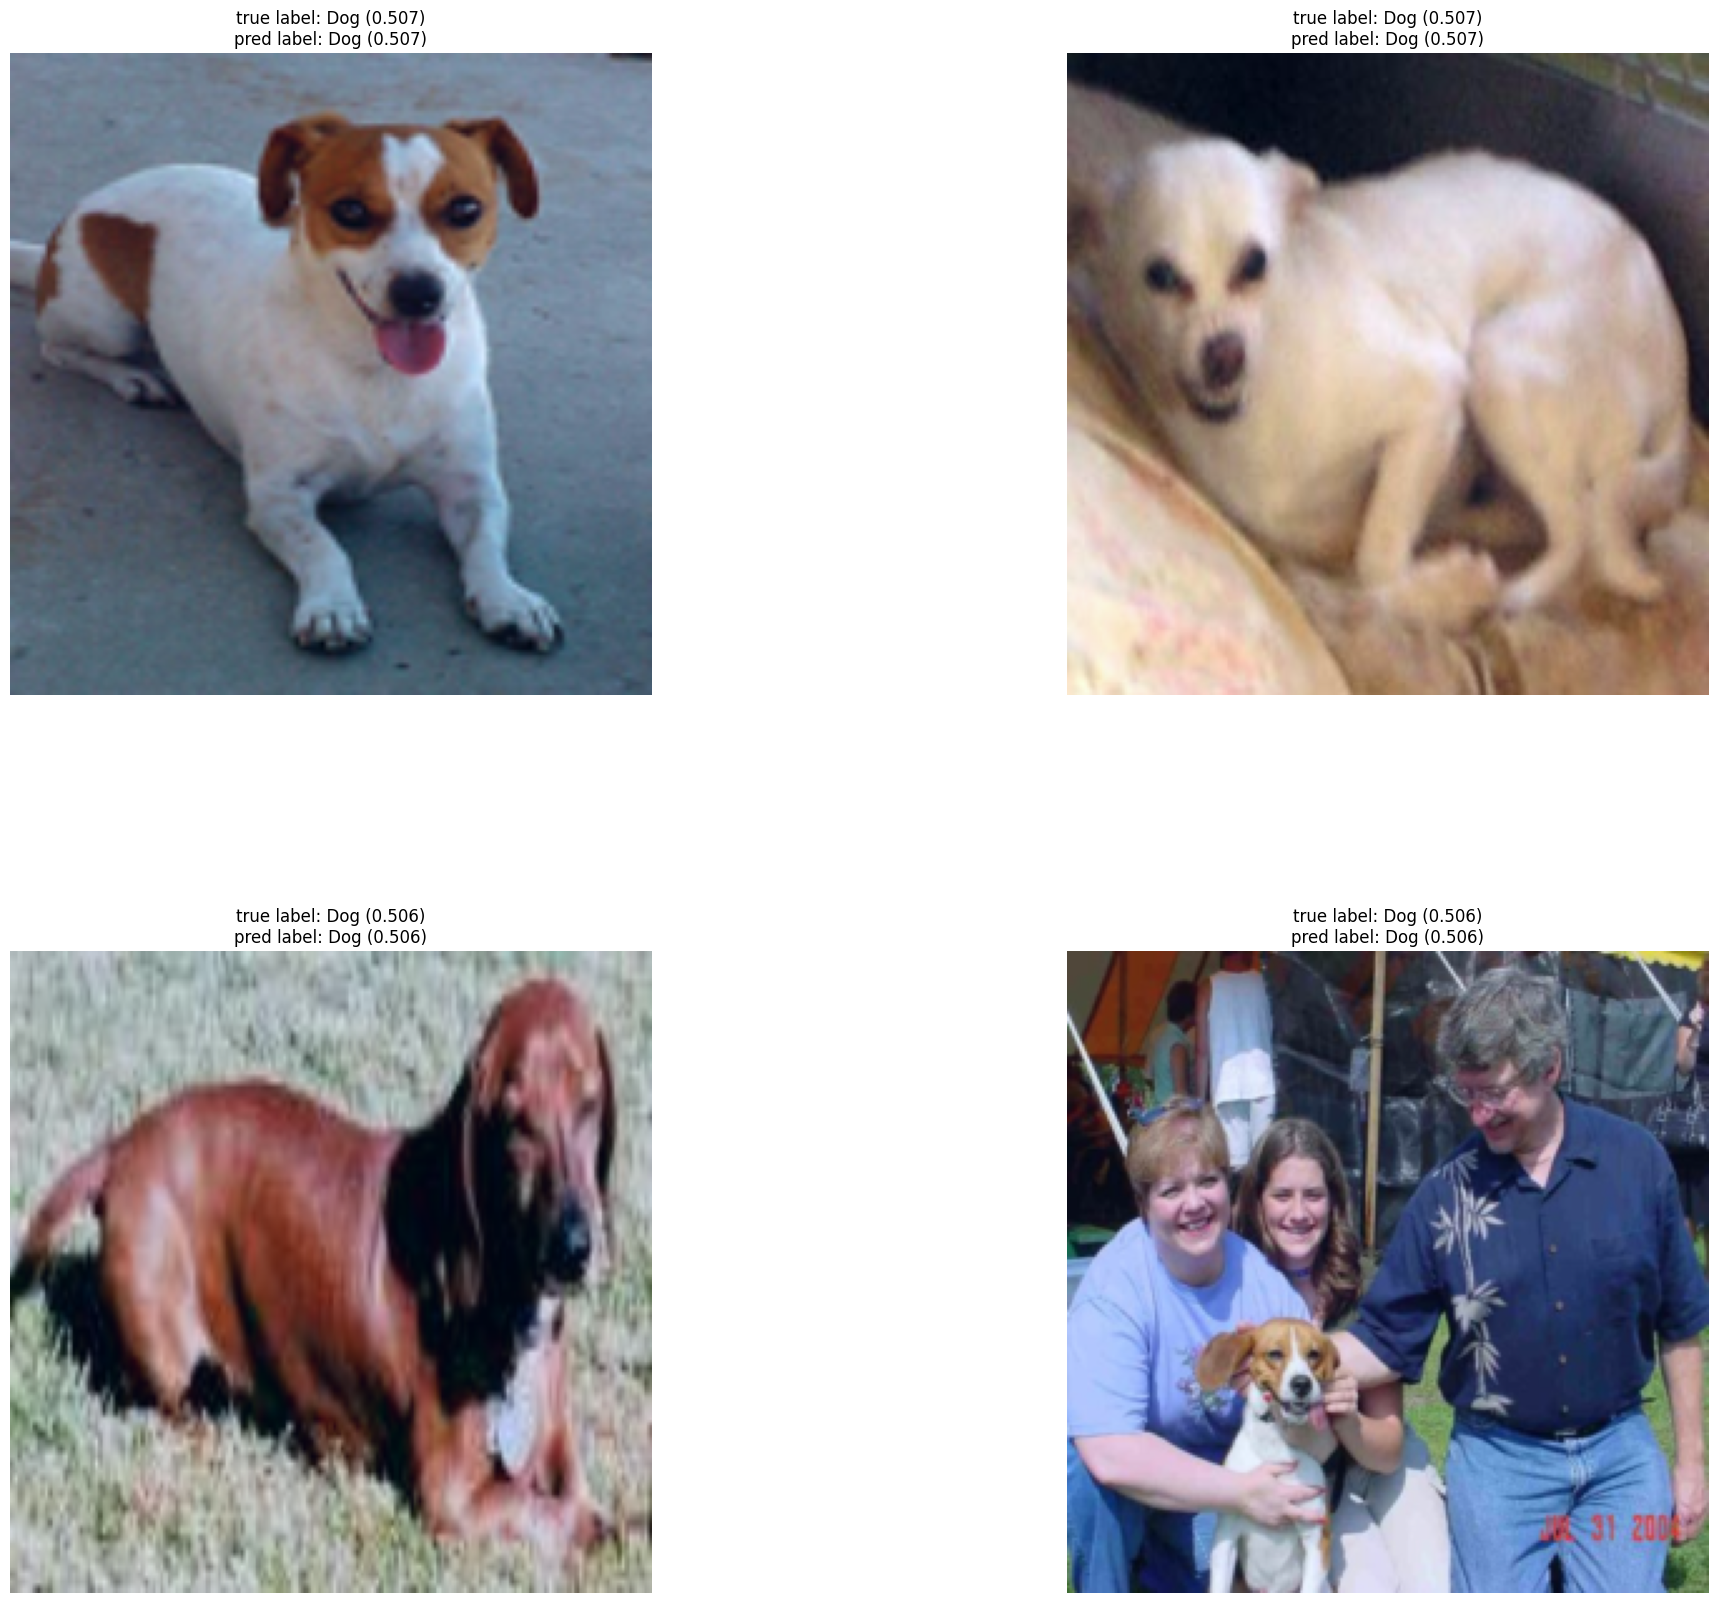

In [42]:
#예측 결과 이미지 출력
import matplotlib.pyplot as plt

classes = test_dataset.classes
N_IMAGES = 5
plot_most_correct(correct_examples, classes, N_IMAGES)